![NWM](img/NWM.png)

# Watershed-Scale Analysis of National Water Model Snow Data
Authors: Irene Garousi-Nejad (igarousi@cuahsi.org)
Last updated:Oct 16, 2025

**Introduction**: This notebook demonstrates how to perform a watershed-scale comparison between modeled and observed SWE at individual SNOTEL sites. It uses National Water Model and Snotel data that is collected in the `01_data_collection.ipynb` notebook. 

### 1. Prepare the Python Environment

In [52]:
import os
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client

from utils import nwm_utils

### 1b. Dask  

We'll use dask to parallelize our code. To manage parallel computation and visualize progress of long-running tasks, we initialize a Dask “cluster,” which defines how many workers are used and how much computing power each worker has. 

In this setup, we create a Dask client with `Client(n_workers=6, threads_per_worker=1, memory_limit='2GB')`, which launches a cluster with 6 workers. Each worker uses a single thread, typically mapped to one CPU core, allowing for efficient parallel processing across 6 cores. Each worker also has a memory limit of 2 GB, for a total of up to 12 GB across the cluster.

In [ ]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print('Dashboard link:', client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    client = Client(n_workers=6, threads_per_worker=1, memory_limit='2GB') 
    print('Dashboard link:', client.dashboard_link)
print(client)

Dashboard link: http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:56464' processes=6 threads=6, memory=11.18 GiB>


2026-02-20 16:24:53,712 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:56479', name: 0, status: running, memory: 0, processing: 0>
2026-02-20 16:24:53,722 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:56481', name: 3, status: running, memory: 0, processing: 0>
2026-02-20 16:24:53,722 - distributed.scheduler - WARNING - Worker failed to heartbeat within 300 seconds. Closing: <WorkerState 'tcp://127.0.0.1:56489', name: 2, status: running, memory: 0, processing: 0>
2026-02-20 16:24:53,732 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:56481'.
2026-02-20 16:24:53,736 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:56479'.
2026-02-20 16:24:53,745 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:564

### 2. Subset the modeled dataset to the watershed of interest

In this notebook, we take a deeper dive into analyzing the NWM snow data across the entire Tuolumne River watershed. To do so, we'll first need to clip the gridded dataset to the watershed boundary, enabling us to compute spatial averages over the region. To begin, we will create a single geometry for the watershed by dissolving all HUC8-level basins within it.

In [42]:
# Start and end times of a water year (note that this code currently works for one water year)
StartDate = '2018-10-01'
EndDate = '2020-09-30'

# Path to NWM snow data
conus_bucket_url = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr'

# file retrieved using `curl -L https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson -o all_stations.geojson`
snotel_geojson = "./domain_data/all_stations.geojson"

# Path to the watershed & basin shapefiles
watershed = "./domain_data/TolumneRiver_18040009.shp"
basin = "./domain_data/DonPedroDam_Upstream_Basin.shp"

Do some GIS stuff

In [19]:

# Extract the bounding box coordinates of a watershed
watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).to_crs(epsg=4326)

# Create a single geometry for the watershed by dissolving all HUC8-level basins within it.
watershed_huc8 = watershed_gdf.dissolve(by='HUC_8')

# Create geodataframe of all stations
all_stations_gdf = gpd.read_file(snotel_geojson).set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]
filtered_all_stations_gdf = all_stations_gdf[all_stations_gdf.state.str.contains('California')]  

# Extract the bounding box coordinates of a watershed
watershed_gdf = gpd.read_file(os.path.join(os.getcwd(), watershed)).to_crs(epsg=4326)

# Combine all polygons into a single MultiPolygon
watershed_union = watershed_gdf.geometry.unary_union

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = filtered_all_stations_gdf[filtered_all_stations_gdf.geometry.within(watershed_union)]
gdf_in_bbox.reset_index(inplace=True)
print(f'There are {len(gdf_in_bbox)} sites from', ', '.join(set(gdf_in_bbox.network)), 'network(s) within the watershed.')


There are 8 sites from CCSS network(s) within the watershed.


We first ensure that the NWM data is loaded and that the domain of interest uses the same coordinate reference system (CRS) as the NWM dataset. This is required when clipping the dataset using rioxarray’s clip method later 

In [20]:
%time 
ds = xr.open_zarr(store=conus_bucket_url, 
                        consolidated=True, 
                        storage_options={
                        "anon": True,
                        "client_kwargs": {"region_name": "us-east-1"}
                    })
ds.rio.set_crs(ds.crs.attrs['esri_pe_string'])
ds.rio.write_crs(inplace=True);
watershed_huc8_prj = watershed_huc8.to_crs(ds.rio.crs)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 4.29 μs


Let's clip the gridded data to the extent of this watershed. This can be done using `rioxarray`'s "clip" method.

In [21]:
%%time
ds_clip = ds.rio.clip(
         watershed_huc8_prj.geometry.values,
         watershed_huc8_prj.crs,
         all_touched=True,   # select all grid cells that touch the vector boundary
         drop=True,          # drop anything that is outside the clipped region
         invert=False,
         from_disk=True).sel(time=slice(StartDate, EndDate))

CPU times: user 2.32 s, sys: 77.9 ms, total: 2.4 s
Wall time: 2.42 s


Preview the data at a specific point in time by defining an **exact date and time** (e.g., '2019-02-01T00:00') or an **index** (e.g., 1000, referring to the 1000th time step in the data array). We will use `hvplot` and `Holoviews` Python packages to create a more informative plot that displays both the gridded data and the vector data. One important note: for `hvplot` to visualize gridded data correctly on a map, all data must be in a **geographic coordinate system** (e.g., EPSG:4326). Note that it may take a while for the following task (map visualization) to be completed.

In [22]:
# Explore the time values
ds_clip.time.values

array(['2018-10-01T00:00:00.000000000', '2018-10-01T03:00:00.000000000',
       '2018-10-01T06:00:00.000000000', ...,
       '2020-09-30T15:00:00.000000000', '2020-09-30T18:00:00.000000000',
       '2020-09-30T21:00:00.000000000'], dtype='datetime64[ns]')

In [23]:
# Explore the variable of interest. We will be working with SNEQV, which is SWE. But feel free to explore other varibales. Note that for some of these varibales, the dimension is different and the funciton may not work for all.
ds_clip.data_vars

Data variables:
    ACCET     (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    ACSNOM    (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    ALBEDO    (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    ALBSND    (time, y, vis_nir, x) float64 dask.array<chunksize=(137, 66, 1, 91), meta=np.ndarray>
    ALBSNI    (time, y, vis_nir, x) float64 dask.array<chunksize=(137, 66, 1, 91), meta=np.ndarray>
    COSZ      (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    EDIR      (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    FIRA      (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    FSA       (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    FSNO      (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.ndarray>
    HFX       (time, y, x) float64 dask.array<chunksize=(137, 66, 91), meta=np.n

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
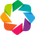

/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.90 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
   .Polygons.I :Polygons   [Longitude,Latitude]
   .Points.I   :Points   [longitude,latitude]   (name)

2026-02-20 16:24:53,734 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-02-20 16:24:53,738 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.
2026-02-20 16:24:53,745 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/worker.py", line 1252, in heartbeat
    response = await retry_operation(
  File "/opt/homebrew/Caskroom/miniconda/base/envs/nwm_env/lib/python3.10/site-packages/distributed/util

In [ ]:
# Define the time and variable of interest
data_var='SNEQV'
time_index='2019-01-01T00:00:00.000000000'

nwm_utils.plot_grid_vector_data(ds_clip, data_var, time_index, watershed_huc8, gdf_in_bbox)

Go ahead and play around with the time slider above to see how SWE changes over time across the watershed. 

<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🔍 Explore</h4>
  <p>
    Using the zoom options in the hvplot toolbar, can you comment on the possible reasons for the missing values or pixels visible on the map?
  </p>
</div>

### 3. Compare the spatial average SWE across the entire watershed

This analysis requires us to compute the spatial average for both observed and modeled snow water equivilent data and create a single Pandas DataFrame that combines the basin-averaged modeled data with the observed data for direct comparison. To do this, we'll read the observed data collected in the `01_data_collection.ipynb` notebook. 

In [35]:
# Observed data
df_obs_swe_mean = nwm_utils.compute_spatial_agg_from_obs('./obs_outputs', 'mean')
df_obs_swe_mean['Date'] = pd.to_datetime(df_obs_swe_mean['Date']).dt.date


In [34]:
# Modeled data
ds_clip_swe_mean = ds_clip.SNEQV.mean(dim=(['x', 'y'])).sel(time=slice(StartDate, EndDate)).compute()
df_mod_swe_mean = nwm_utils.prep_nwm_swe_dataframe(ds_clip_swe_mean, gdf_in_bbox.iloc[0].state)
df_mod_swe_mean['Date_Local'] = pd.to_datetime(df_mod_swe_mean['Date_Local']).dt.date

In [37]:
# Combine
combined_df_mean = pd.merge(
    df_mod_swe_mean, df_obs_swe_mean, 
    left_on='Date_Local',  
    right_on='Date',       
    how='inner'  
)
combined_df_mean = combined_df_mean[['Date_Local', 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters']]
combined_df_mean.index = pd.to_datetime(combined_df_mean['Date_Local'])


Create plots and compute stats

In [39]:
# Plot
nwm_utils.comparison_plots(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

:Layout
   .Overlay.I  :Overlay
      .Curve.Observed_SWE :Curve   [date]   (Snow Water Equivalent (m) Start of Day Values)
      .Curve.Modeled_SWE  :Curve   [date]   (NWM_SWE_meters)
   .Overlay.II :Overlay
      .Scatter.I              :Scatter   [Snow Water Equivalent (m) Start of Day Values]   (NWM_SWE_meters,date)
      .Curve.A_1_colon_1_Line :Curve   [x]   (y)

In [40]:
# Stats
nwm_utils.compute_stats(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

,Mean [L],Median [L],Standard Deviation [L],Variance [L^2],Min [L],Max [L]
observed,0.279148,0.131717,0.380916,0.145097,0.0,1.324429
modeled,0.093878,0.04485,0.125349,0.015712,0.0,0.440114
,,,,,,
Pearson Correlation [-],0.989945,,,,,
Spearman Correlation [-],0.969057,,,,,
Bias (Modeled - Observed) [L],-0.18527,,,,,
Nash-Sutcliffe Efficiency (NSE) [-],0.30635,,,,,
Kling-Gupta Efficiency (KGE) [-],0.056211,,,,,


<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    What could be the potential sources of discrepancies between the spatially averaged SWE from the modeled and observed datasets within this catchment?  
How could you generate more reliable or informative statistics?  
How do you think the presence of SWE values equal to zero across large areas of the gridded dataset (as seen in the map above) — particularly when this pattern is consistent across the water year — might impact the spatially averaged SWE values?  
How could this influence your interpretation?
  </p>
</div>

### 4. Compare the spatial average SWE across a catchment within the watershed

#### Don Pedro Reservoir Basin

Repeat the steps above, but this time focus on a smaller domain. For example, the upstream catchments of the Don Pedro Reservoir (DonPedroDam_Upstream_Basin.shp). This allows us to examine the impact of excluding areas where SWE is zero for the majority of days within a water year. Could this approach improve the statistical comparison between modeled and observed SWE?

In [43]:
donpedro_gdf = gpd.read_file(os.path.join(os.getcwd(), basin)).to_crs(epsg=4326)
donpedro_gdf_prj = donpedro_gdf.to_crs(ds.rio.crs)
ds_clip_donpedro = ds.rio.clip(
         donpedro_gdf_prj.geometry.values,
         donpedro_gdf_prj.crs,
         all_touched=True,   
         drop=True,         
         invert=False,
         from_disk=True).sel(time=slice(StartDate, EndDate))

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
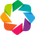

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
   .Polygons.I :Polygons   [Longitude,Latitude]
   .Points.I   :Points   [longitude,latitude]   (name)

In [44]:
# Define the time and variable of interest
data_var='SNEQV'
time_index='2019-01-01T00:00:00.000000000'

nwm_utils.plot_grid_vector_data(ds_clip_donpedro, data_var, time_index, donpedro_gdf, gdf_in_bbox)

In [45]:
# Modeled data
ds_clip_swe_mean = ds_clip_donpedro.SNEQV.mean(dim=(['x', 'y'])).sel(time=slice(StartDate, EndDate)).compute()
df_mod_swe_mean = nwm_utils.prep_nwm_swe_dataframe(ds_clip_swe_mean, gdf_in_bbox.iloc[0].state)

# Observed data
df_obs_swe_mean = nwm_utils.compute_spatial_agg_from_obs('./obs_outputs', 'mean')
df_obs_swe_mean['Date'] = pd.to_datetime(df_obs_swe_mean['Date']).dt.date
df_mod_swe_mean['Date_Local'] = pd.to_datetime(df_mod_swe_mean['Date_Local']).dt.date

# Combine with the observed data
combined_df_mean = pd.merge(
    df_mod_swe_mean, df_obs_swe_mean, 
    left_on='Date_Local',  
    right_on='Date',       
    how='inner'  
)
combined_df_mean = combined_df_mean[['Date_Local', 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters']]
combined_df_mean.index = pd.to_datetime(combined_df_mean['Date_Local'])

# Plot
nwm_utils.comparison_plots(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

:Layout
   .Overlay.I  :Overlay
      .Curve.Observed_SWE :Curve   [date]   (Snow Water Equivalent (m) Start of Day Values)
      .Curve.Modeled_SWE  :Curve   [date]   (NWM_SWE_meters)
   .Overlay.II :Overlay
      .Scatter.I              :Scatter   [Snow Water Equivalent (m) Start of Day Values]   (NWM_SWE_meters,date)
      .Curve.A_1_colon_1_Line :Curve   [x]   (y)

In [46]:
# Stats
nwm_utils.compute_stats(combined_df_mean, 'Snow Water Equivalent (m) Start of Day Values', 'NWM_SWE_meters')

,Mean [L],Median [L],Standard Deviation [L],Variance [L^2],Min [L],Max [L]
observed,0.279148,0.131717,0.380916,0.145097,0.0,1.324429
modeled,0.139215,0.06653,0.185881,0.034552,0.0,0.652939
,,,,,,
Pearson Correlation [-],0.990033,,,,,
Spearman Correlation [-],0.969059,,,,,
Bias (Modeled - Observed) [L],-0.139933,,,,,
Nash-Sutcliffe Efficiency (NSE) [-],0.592974,,,,,
Kling-Gupta Efficiency (KGE) [-],0.283377,,,,,


Visualize both the temporal and spatial variability of modeled SWE across the domain. To achieve this, we first create a subset of the modeled data by selecting only the first time step of each month from the simulated SWE dataset. To improve processing efficiency, we chunk the dataset along the time dimension, allowing faster access to individual time slices. We then apply a time filter and compute each selected slice individually to avoid excessive memory use. Finally, we combine the computed slices back into a single dataset for analysis and visualization.

In [47]:
# Check the current chunks
ds_clip_donpedro.chunks

Frozen({'time': (137, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 224, 111), 'y': (66,), 'x': (9, 81), 'vis_nir': (1, 1), 'soil_layers_stag': (1, 1, 1, 1)})

In [48]:
# Rechunck
ds_clip_donpedro = ds_clip_donpedro.chunk({'time': 1})

**Note**: The following code may take several minutes to run.

In [49]:
%%time 

# Apply time filter
mask = (ds_clip_donpedro.time.dt.is_month_start) & (ds_clip_donpedro.time.dt.hour == 0)

# Compute in smaller pieces
selected_times = ds_clip_donpedro.time[mask]
parts = []
for t in selected_times.values:
    part = ds_clip_donpedro.sel(time=t).compute()  # One slice at a time
    parts.append(part)

# Combine the pieces
ds_monthly_start = xr.concat(parts, dim='time')

CPU times: user 2min 40s, sys: 1min 7s, total: 3min 48s
Wall time: 5min


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
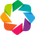

:Layout
   .Overlay.I     :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.II    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.III   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.IV    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.V     :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.VI    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.VII   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.VIII  :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.IX    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.X     :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XI    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XII   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XIII  :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XIV   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XV    :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water equivalent)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Points.I   :Points   [longitude,latitude]   (name)
   .Overlay.XVI   :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [longitude,latitude]   (Snow water e

In [50]:
data_var='SNEQV'
nwm_utils.plot_grid_vector_monthly_data(ds_monthly_start, data_var, donpedro_gdf, gdf_in_bbox)

<div style="color:black; background-color:#f5f5f5; padding:10px; border-left: 5px solid #007acc;">
  <h4>🧠 Reflect</h4>
  <p>
    In the plot above, you can see that in both accumulation and melt periods (e.g., Feb-Jun), snow was present in areas not covered by the existing observation points.  
How would having more observation points distributed across these snow-covered areas affect the basin-average SWE from observations, as calculated and plotted previously (`combined_df_mean`)?  
How could this change influence the bias, Nash-Sutcliffe Efficiency (NSE), and other statistical comparisons between modeled and observed SWE?  
And, how might improving the capture of spatial variability in SWE affect forecasts under future climate conditions?
  </p>
</div>

### Peak SWE

In [ ]:
peak_swe = grid_swe_da.max(dim="time")
peak_day = grid_swe_da.idxmax(dim="time")
